# Job Information

When applying the techniques in the previous notebooks, we will want to understand the scale and scope of our work better.

Some things we might want to know on a job include:
- How many acres is the total mapped area?
    - Can we see the area divided into 1-acre plots?
- How many total plants are detected?
    - How much product is needed to treat all of these plants?
- How long is the journey to treat all plants?
    - How many drone batteries might that take?

This notebook will provide code to help answer some of these questions.

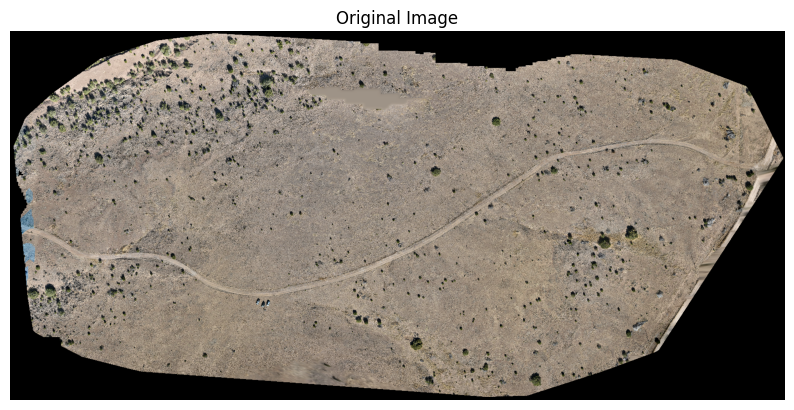

Scaled image dimensions: (809, 1701, 3)


In [1]:
import sys
from pathlib import Path

# Add the parent directory to the Python path
# So we can find local modules e.g. "plant_search"
sys.path.append(str(Path.cwd().parent))

from plant_search.load_image import load_image, plot_image


# file_path = 'input/ESPG-4326-orthophoto.tif'
# file_path = 'input/MADRID_RGB.tif'
# file_path = '../input/aerial-trees.jpg'

# file_path = '../input/DJI_0010.JPG'
# file_path = '../input/DJI_0015.JPG'
# file_path = '../input/DJI_0093.JPG'
# file_path = '../input/DJI_0119.JPG'
file_path = '../input/IGNORE_Brewster-ortho.tif'

ds = 8 # downscale ratio

image = load_image(file_path)
if image is not None:
    image = image[::ds, ::ds]
    plot_image(image, "Original Image")

print(f"Scaled image dimensions: {image.shape}")

In [3]:
import rasterio
from pyproj import Geod
import numpy as np
import geopandas as gpd
from shapely.geometry import box

def calculate_acreage_without_reproject(bounds, width, height, crs):
    geod = Geod(ellps="WGS84")  # Use the WGS84 ellipsoid for distance calculations
    
    # Calculate pixel size in meters
    x_pixels = width
    y_pixels = height
    pixel_width_deg = (bounds.right - bounds.left) / x_pixels
    pixel_height_deg = (bounds.top - bounds.bottom) / y_pixels
    
    # Approximate area of the full raster using geodesic calculation
    total_area_m2, _ = geod.geometry_area_perimeter(box(bounds.left, bounds.bottom, bounds.right, bounds.top))
    total_area_acres = total_area_m2 / 4046.86
    return total_area_acres, pixel_width_deg, pixel_height_deg

def generate_one_acre_grids(bounds, crs, pixel_width_deg, pixel_height_deg):
    # Approximate degree size for 1 acre in the current CRS
    one_acre_m2 = 4046.86
    grid_boxes = []
    
    # Step size approximation for 1 acre in degrees (latitude and longitude)
    step_lat = pixel_height_deg * (one_acre_m2 ** 0.5 / pixel_height_deg)
    step_lon = pixel_width_deg * (one_acre_m2 ** 0.5 / pixel_width_deg)
    
    # Generate grid
    y_coords = np.arange(bounds.bottom, bounds.top, step_lat)
    x_coords = np.arange(bounds.left, bounds.right, step_lon)
    
    for x in x_coords:
        for y in y_coords:
            grid_boxes.append(box(x, y, x + step_lon, y + step_lat))
    
    grid_gdf = gpd.GeoDataFrame({"geometry": grid_boxes}, crs=crs)
    return grid_gdf

# Example usage
geotiff_path = file_path

with rasterio.open(geotiff_path) as src:
    bounds = src.bounds
    width = src.width
    height = src.height
    crs = src.crs

area_acres, pixel_width_deg, pixel_height_deg = calculate_acreage_without_reproject(bounds, width, height, crs)
grid_gdf = generate_one_acre_grids(bounds, crs, pixel_width_deg, pixel_height_deg)

print(f"Total Area: {area_acres:.2f} acres")


Total Area: 72.01 acres


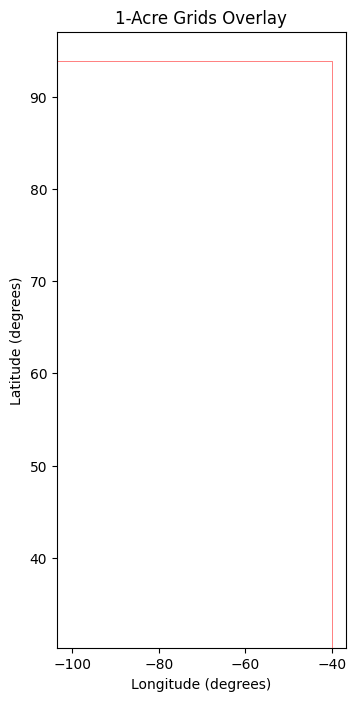

In [ ]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import geopandas as gpd

def visualize_1_acre_grids(raster_path, grid_gdf):
    # Open the raster file
    with rasterio.open(raster_path) as src:
        # Plot the raster
        fig, ax = plt.subplots(figsize=(12, 8))
        raster_extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
        show(src, extent=raster_extent, ax=ax, cmap='gray')
        
        # Plot the 1-acre grid
        grid_gdf.boundary.plot(ax=ax, edgecolor='red', linewidth=0.5, alpha=0.7)
        
        # Add labels and title
        ax.set_title("1-Acre Grids Overlay")
        ax.set_xlabel("Longitude (degrees)")
        ax.set_ylabel("Latitude (degrees)")
        
        plt.show()

# Filepath to your GeoTIFF
raster_path = file_path

# Visualize the grids
visualize_1_acre_grids(raster_path, grid_gdf)


In [ ]:
import rasterio
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject, Resampling
from shapely.geometry import box
import geopandas as gpd
import matplotlib.pyplot as plt

def reproject_to_meters(src_path, dst_path):
    """Reproject the GeoTIFF to a CRS with meters (e.g., UTM)."""
    with rasterio.open(src_path) as src:
        # Calculate transformation to a projected CRS (UTM based on image center)
        dst_crs = rasterio.crs.CRS.from_epsg(32633)  # Replace with desired EPSG (e.g., UTM zone)
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds
        )
        
        kwargs = src.meta.copy()
        kwargs.update({
            'crs': dst_crs,
            'transform': transform,
            'width': width,
            'height': height
        })
        
        with rasterio.open(dst_path, 'w', **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.nearest
                )
    return dst_path

def reproject_to_meters_optimized(src_path, dst_path, target_crs=None):
    """Reproject the GeoTIFF to a CRS with meters, matching the original resolution and applying compression."""
    with rasterio.open(src_path) as src:
        # Set target CRS (default: UTM based on the image center)
        if target_crs is None:
            centroid = ((src.bounds.left + src.bounds.right) / 2, 
                        (src.bounds.top + src.bounds.bottom) / 2)
            utm_zone = int((centroid[0] + 180) // 6) + 1
            is_northern = centroid[1] >= 0
            target_crs = f"EPSG:{32600 + utm_zone if is_northern else 32700 + utm_zone}"
        
        transform, width, height = calculate_default_transform(
            src.crs, target_crs, src.width, src.height, *src.bounds
        )
        
        # Match resolution to the original
        dst_resolution = (src.res[0], src.res[1])
        width = int((src.bounds.right - src.bounds.left) / dst_resolution[0])
        height = int((src.bounds.top - src.bounds.bottom) / dst_resolution[1])
        
        kwargs = src.meta.copy()
        kwargs.update({
            'crs': target_crs,
            'transform': transform,
            'width': width,
            'height': height,
            'compress': 'lzw'  # Add compression
        })
        
        with rasterio.open(dst_path, 'w', **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=target_crs,
                    resampling=Resampling.nearest  # Use nearest neighbor for speed
                )
    return dst_path


def load_geotiff(filepath):
    # Load the GeoTIFF file
    with rasterio.open(filepath) as src:
        bounds = src.bounds
        resolution = src.res
        crs = src.crs
        data = src.read(1)  # Load the first band (can be adjusted based on the file)
        
    return bounds, resolution, crs, data

def calculate_acreage(bounds):
    # Calculate the acreage of the image
    width = bounds.right - bounds.left  # in meters
    height = bounds.top - bounds.bottom  # in meters
    area_m2 = width * height  # Area in square meters
    area_acres = area_m2 / 4046.86  # Convert square meters to acres
    return area_acres

def draw_acre_regions(bounds, crs):
    # Create a grid of 1-acre boxes
    one_acre_m = 4046.86  # 1 acre in square meters
    width = bounds.right - bounds.left
    height = bounds.top - bounds.bottom
    
    grid_boxes = []
    x_step = y_step = one_acre_m ** 0.5  # Convert 1 acre to square side length in meters
    
    x_min, x_max = bounds.left, bounds.right
    y_min, y_max = bounds.bottom, bounds.top

    # Generate the grid
    x_coords = list(range(int(x_min), int(x_max), int(x_step)))
    y_coords = list(range(int(y_min), int(y_max), int(y_step)))
    
    for x in x_coords:
        for y in y_coords:
            # Create a box for each 1-acre region
            grid_boxes.append(box(x, y, x + x_step, y + y_step))
    
    # Create a GeoDataFrame for the grid
    grid_gdf = gpd.GeoDataFrame({"geometry": grid_boxes}, crs=crs)
    return grid_gdf

def plot_with_regions(data, grid_gdf, bounds, crs):
    # Plot the raster data and overlay the grid
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot the raster
    raster_extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    ax.imshow(data, extent=raster_extent, cmap="gray", origin="upper")
    
    # Plot the grid
    grid_gdf.boundary.plot(ax=ax, color="red", linewidth=0.5, alpha=0.7)
    
    # Set equal aspect manually
    ax.set_aspect("equal")
    
    plt.title("1-Acre Regions on the GeoTIFF")
    plt.show()


# Filepath to your GeoTIFF
reprojected_path = "../outputs/10_job_info/reprojected.tif"

# Reproject the GeoTIFF to meters-based CRS
# reproject_to_meters(file_path, reprojected_path)
reproject_to_meters_optimized(file_path, reprojected_path)

# Process the GeoTIFF
bounds, resolution, crs, data = load_geotiff(reprojected_path)
area_acres = calculate_acreage(bounds)

print(f"Total Area: {area_acres:.2f} acres")

# Plot the GeoTIFF with 1-acre regions
# grid_gdf = draw_acre_regions(bounds, crs)
# plot_with_regions(data, grid_gdf, bounds, crs)

# 370.08 acres?
# 66.26 acres second run
